In [ ]:
!kaggle datasets download vbookshelf/v2-plant-seedlings-dataset

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/v2-plant-seedlings-dataset
License(s): CC-BY-SA-4.0
100% 3.19G/3.19G [03:09<00:00, 18.1MB/s]



In [ ]:
!unzip /content/v2-plant-seedlings-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: nonsegmentedv2/Charlock/308.png  
  inflating: nonsegmentedv2/Charlock/309.png  
  inflating: nonsegmentedv2/Charlock/31.png  
  inflating: nonsegmentedv2/Charlock/310.png  
  inflating: nonsegmentedv2/Charlock/311.png  
  inflating: nonsegmentedv2/Charlock/312.png  
  inflating: nonsegmentedv2/Charlock/313.png  
  inflating: nonsegmentedv2/Charlock/314.png  
  inflating: nonsegmentedv2/Charlock/315.png  
  inflating: nonsegmentedv2/Charlock/316.png  
  inflating: nonsegmentedv2/Charlock/317.png  
  inflating: nonsegmentedv2/Charlock/318.png  
  inflating: nonsegmentedv2/Charlock/319.png  
  inflating: nonsegmentedv2/Charlock/32.png  
  inflating: nonsegmentedv2/Charlock/320.png  
  inflating: nonsegmentedv2/Charlock/321.png  
  inflating: nonsegmentedv2/Charlock/322.png  
  inflating: nonsegmentedv2/Charlock/323.png  
  inflating: nonsegmentedv2/Charlock/324.png  
  inflating: nonsegmentedv2/Charlock/325.png  
  inflating

In [ ]:
!ls

 Black-grass	    'Fat Hen'		'Scentless Mayweed'
 Charlock	    'Loose Silky-bent'	'ShepherdтАЩs Purse'
 Cleavers	     Maize		'Small-flowered Cranesbill'
'Common Chickweed'   nonsegmentedv2	'Sugar beet'
'Common wheat'	     sample_data	 v2-plant-seedlings-dataset.zip


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [ ]:
device

'cuda'

In [ ]:
DATA_DIR = 'nonsegmentedv2'
classes = sorted(os.listdir(DATA_DIR))
num_classes = len(classes)

In [ ]:
num_classes

12

In [ ]:
# nonsegmentedv2/ Black-grass/rhhfh.png

In [ ]:
for cls in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f'{cls}: {count}')

Black-grass: 309
Charlock: 452
Cleavers: 335
Common Chickweed: 713
Common wheat: 253
Fat Hen: 538
Loose Silky-bent: 762
Maize: 257
Scentless Mayweed: 607
ShepherdтАЩs Purse: 274
Small-flowered Cranesbill: 576
Sugar beet: 463


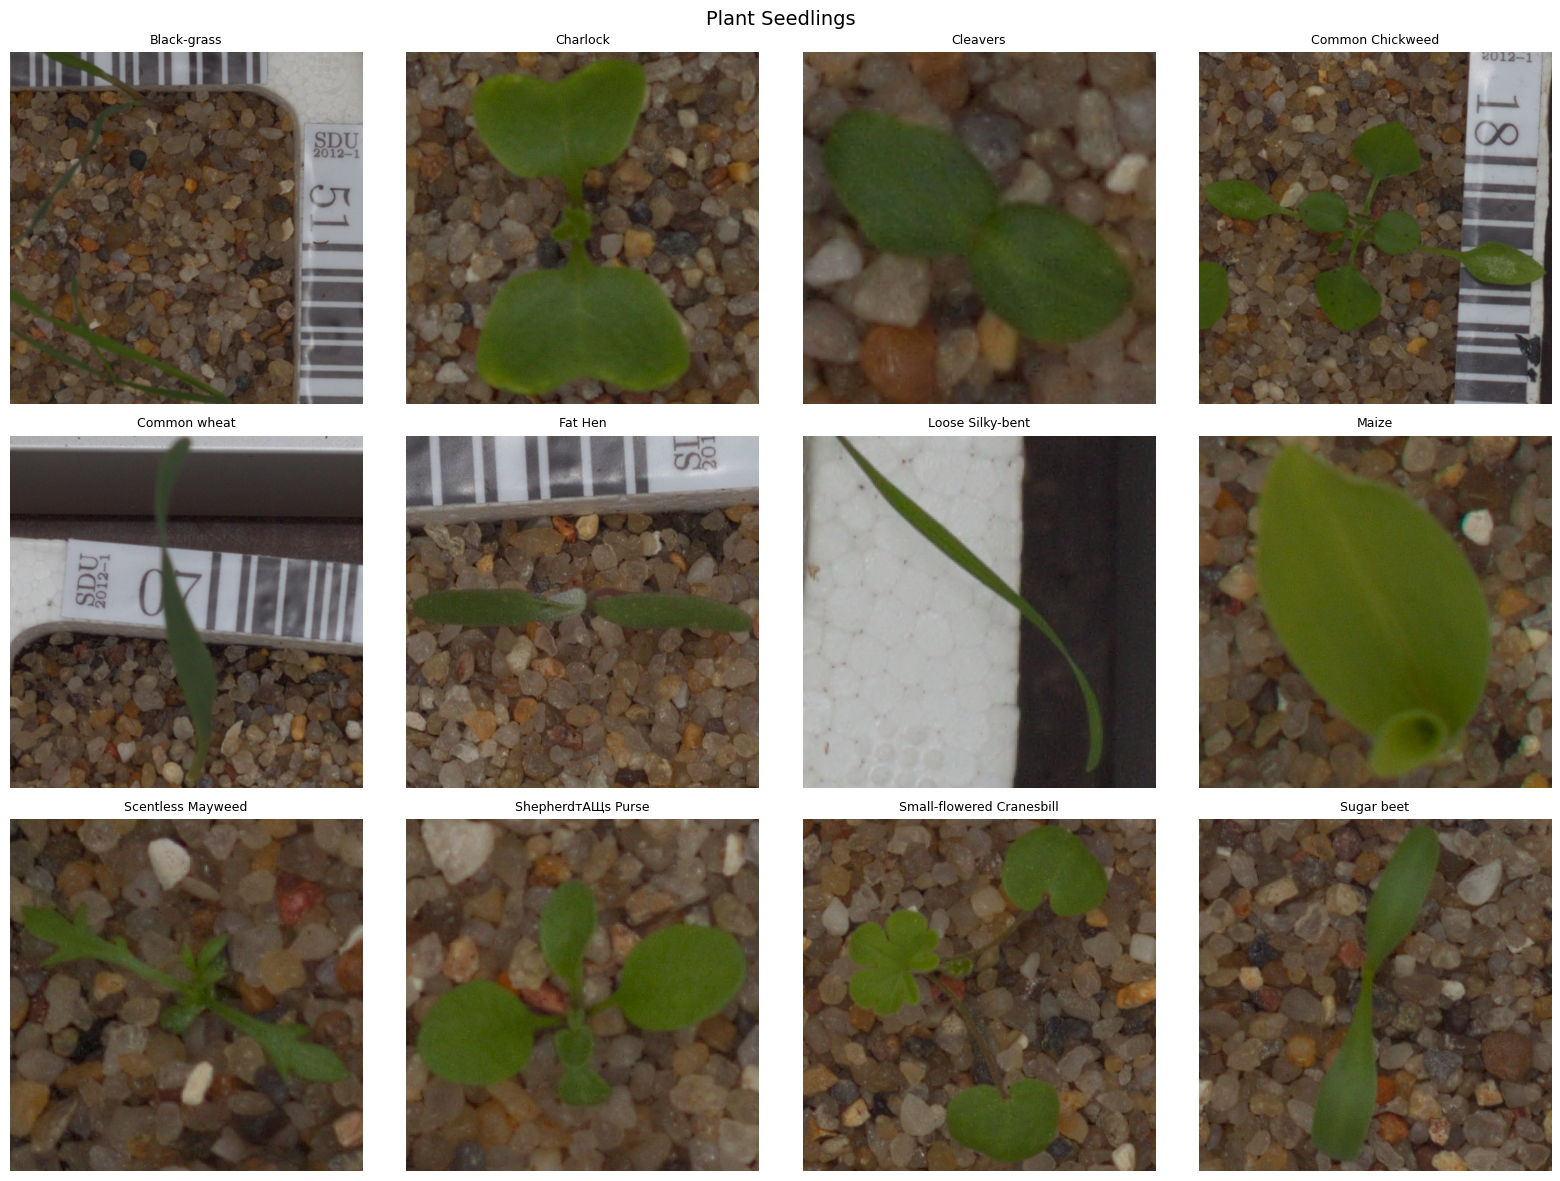

In [ ]:
import PIL.Image as Image
import random

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Plant Seedlings', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE   = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)

total = len(full_dataset)
train_size = int(0.8 * total)
valid_size = total - train_size

train_set, valid_set = random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

valid_set.dataset = datasets.ImageFolder(DATA_DIR, transform=valid_transform)

In [ ]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {train_size}\nValid: {valid_size}')
print(f'class - index: {full_dataset.class_to_idx}')

Train: 4431
Valid: 1108
class - index: {'Black-grass': 0, 'Charlock': 1, 'Cleavers': 2, 'Common Chickweed': 3, 'Common wheat': 4, 'Fat Hen': 5, 'Loose Silky-bent': 6, 'Maize': 7, 'Scentless Mayweed': 8, 'ShepherdтАЩs Purse': 9, 'Small-flowered Cranesbill': 10, 'Sugar beet': 11}


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels=3, num_classes=12, dropout=0.4):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(1024, 512),
              nn.ReLU(),
              nn.Dropout(dropout),
              nn.Linear(512, 128),
              nn.ReLU(),
              nn.Dropout(),
              nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.pool(self.enc1(x))
        x = self.pool(self.enc2(x))
        x = self.pool(self.enc3(x))
        x = self.pool(self.enc4(x))
        x = self.bottleneck(x)
        x = self.gap(x)
        return self.classifier(x)

In [ ]:
model = UNetEncoder(in_channels=3, num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parametrs: {total_params:,}')

Total parametrs: 19,443,148


In [ ]:
dummy = torch.randn(2, 3, 128, 128).to(device)
out = model(dummy)
print(f'Output shape: {out.shape}')

Output shape: torch.Size([2, 12])


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
def valid_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Val Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   'r-', label='Val Acc')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
N_EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4

label_counts = [0] * num_classes
for i in train_set.indices:
    label = full_dataset.targets[i]
    label_counts[label] += 1

class_weights = torch.tensor([1.0 / label_counts[i] for i in range(num_classes)], dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * num_classes

In [ ]:
class_weights

tensor([1.2726, 0.8751, 1.1615, 0.5498, 1.5506, 0.7326, 0.5324, 1.5658, 0.6600,
        1.5210, 0.7036, 0.8751], device='cuda:0')

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

Epoch 1/10
Train Loss: 1.2845
Train Acc: 0.5403
Val Loss: 1.2904
Val Acc: 0.5208
Val Acc: 0.5208
Epoch 2/10
Train Loss: 1.2416
Train Acc: 0.5547
Val Loss: 1.4219
Val Acc: 0.5181
Epoch 3/10
Train Loss: 1.1325
Train Acc: 0.5929
Val Loss: 1.0276
Val Acc: 0.6570
Val Acc: 0.6570
Epoch 4/10
Train Loss: 1.0912
Train Acc: 0.6012
Val Loss: 0.9941
Val Acc: 0.5912
Epoch 5/10
Train Loss: 1.0475
Train Acc: 0.6168
Val Loss: 0.9151
Val Acc: 0.7022
Val Acc: 0.7022
Epoch 6/10
Train Loss: 0.9850
Train Acc: 0.6445
Val Loss: 0.7987
Val Acc: 0.7419
Val Acc: 0.7419
Epoch 7/10
Train Loss: 0.9536
Train Acc: 0.6662
Val Loss: 0.8008
Val Acc: 0.7374
Epoch 8/10
Train Loss: 0.9462
Train Acc: 0.6633
Val Loss: 0.7849
Val Acc: 0.7383
Epoch 9/10
Train Loss: 0.9636
Train Acc: 0.6565
Val Loss: 0.7766
Val Acc: 0.7338
Epoch 10/10
Train Loss: 0.9494
Train Acc: 0.6585
Val Loss: 0.7763
Val Acc: 0.7374
The best accuracy: 0.7419


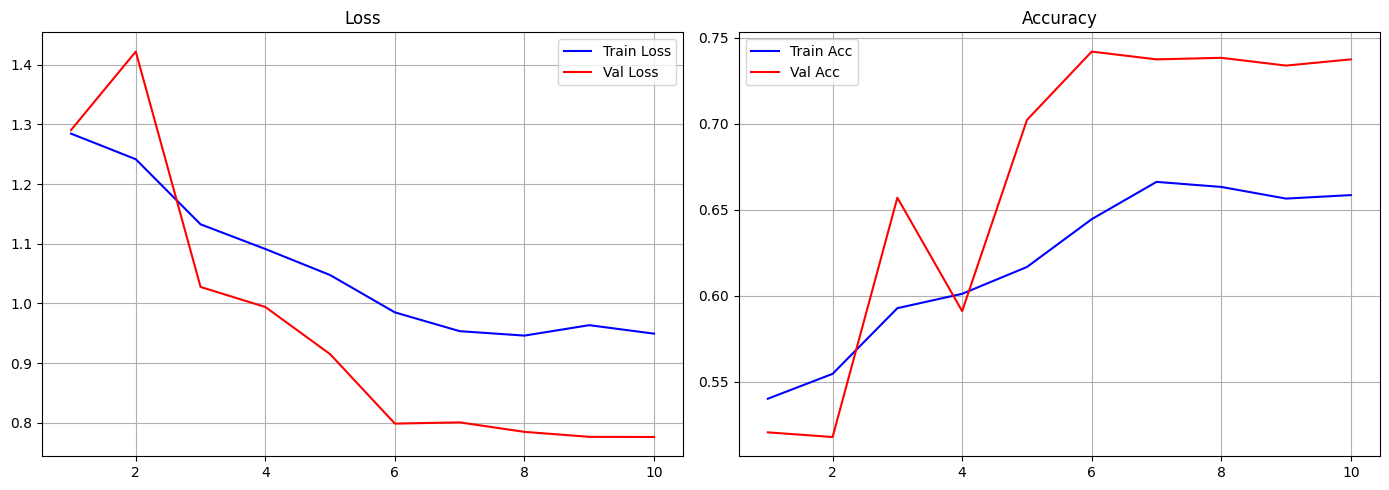

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = valid_epoch(model, valid_loader, criterion, device)
    scheduler.step()
    print(f'Epoch {epoch+1}/{N_EPOCHS}\nTrain Loss: {train_loss:.4f}\nTrain Acc: {train_acc:.4f}\nVal Loss: {val_loss:.4f}\nVal Acc: {val_acc:.4f}')
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f'Val Acc: {best_val_acc:.4f}')

print(f'The best accuracy: {best_val_acc:.4f}')
plot_history(history)